# Contextual Multi-Armed Bandit with BNN-Based Quantitative Model

This notebook demonstrates the usage of a **Bayesian Neural Network (BNN) based quantitative model** for continuous action parameters with the contextual multi-armed bandit (CMAB) implementation in `pybandits`.

The BNN quantitative model maps context features and a continuous action parameter (e.g., price, dosage, bid) to a reward distribution. A Bayesian Neural Network is used to model the relationship between context, the quantitative parameter, and the expected reward, providing uncertainty estimates that support exploration–exploitation. Unlike discrete-action CMABs, this approach lets you learn and optimize over continuous or fine-grained quantitative choices while conditioning on context.

**Key aspects:**
- **Context + quantity**: The model takes both contextual features and a scalar (or vector) quantitative parameter as input.
- **Uncertainty-aware**: The BNN yields a posterior over rewards, which the bandit can use for Thompson sampling or similar strategies.
- **Flexible fitting**: Supports variational inference (VI) or other Bayesian update methods for the BNN weights.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pybandits.cmab import CmabBernoulli
from pybandits.quantitative_model import QuantitativeBayesianNeuralNetwork

rng = np.random.default_rng(seed=42)

%load_ext autoreload
%autoreload 2

/home/runner/.cache/pypoetry/virtualenvs/pybandits-vYJB-miV-py3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup

First, we'll define actions with quantitative parameters. In this example, we'll use two actions, each with a one-dimensional quantitative parameter (e.g., price point or dosage level) ranging from 0 to 1. Unlike the SMAB model, here we also need to define contextual features.

In [2]:
# Define number of features for the context
n_features = 3

# Define cold start parameters for the base model
update_method = "VI"  # Variational Inference for Bayesian updates
update_kwargs = {"num_steps": 50, "optimizer_type": "adam", "optimizer_kwargs": {"step_size": 0.001}}
dist_params_init = {"mu": 0, "sigma": 10, "nu": 5}

# Define actions with zooming models
actions = {
    "action_1": QuantitativeBayesianNeuralNetwork.cold_start(
        dimension=1,
        n_features=n_features,
        base_model_cold_start_kwargs=dict(
            hidden_dim_list=[10],
            update_method="VI",
            update_kwargs=update_kwargs,
            dist_params_init=dist_params_init,
            activation="tanh",
        ),
    ),
    "action_2": QuantitativeBayesianNeuralNetwork.cold_start(
        dimension=1,
        n_features=n_features,
        base_model_cold_start_kwargs=dict(
            hidden_dim_list=[10],
            update_method="VI",
            update_kwargs=update_kwargs,
            dist_params_init=dist_params_init,
            activation="tanh",
        ),
    ),
}

In [3]:
actions["action_1"].bnn.update_kwargs

{'num_steps': 50,
 'method': 'advi',
 'optimizer_type': 'adam',
 'optimizer_kwargs': {'step_size': 0.001},
 'batch_size': None,
 'early_stopping_kwargs': None,
 'lr_scheduler_type': None,
 'lr_scheduler_kwargs': None,
 'restore_best_svi_state': True,
 'num_particles': 1,
 'gradient_clip_norm': None}

Now we can initialize the CmabBernoulli bandit with our zooming models:

In [4]:
# Initialize the bandit
cmab = CmabBernoulli(actions=actions, epsilon=1)

In [5]:
print(cmab.actions["action_1"].bnn.update_kwargs)
print(f"epsilon: {cmab.epsilon}")

{'num_steps': 50, 'method': 'advi', 'optimizer_type': 'adam', 'optimizer_kwargs': {'step_size': 0.001}, 'batch_size': None, 'early_stopping_kwargs': None, 'lr_scheduler_type': None, 'lr_scheduler_kwargs': None, 'restore_best_svi_state': True, 'num_particles': 1, 'gradient_clip_norm': None}
epsilon: 1.0


## Simulate Environment

Let's create a reward function that depends on both the action, its quantitative parameter, and the context. For illustration purposes, we'll define that:

- `action_1` performs better when the first context feature is high and when the quantitative parameter is around 0.25
- `action_2` performs better when the second context feature is high and when the quantitative parameter is around 0.75

The reward probability follows a bell curve for the quantitative parameter and is also influenced by the context features.

In [6]:
def reward_function(action, quantity, context):
    if action == "action_1":
        # Bell curve centered at 0.25 for the quantity
        # Influenced by first context feature
        quantity_component = np.exp(-((quantity - 0.25) ** 2) / 0.02)
        context_component = 0.5 + 0.5 * (context[0] / 2)  # First feature has influence
        prob = quantity_component * context_component
    else:  # action_2
        # Bell curve centered at 0.75 for the quantity
        # Influenced by second context feature
        quantity_component = np.exp(-((quantity - 0.75) ** 2) / 0.02)
        context_component = 0.5 + 0.5 * (context[1] / 2)  # Second feature has influence
        prob = quantity_component * context_component

    # Ensure probability is between 0 and 1
    prob = max(0, min(1, prob))

    return np.random.binomial(1, prob), prob


def get_optimal_reward(context):
    max_prob_action_1 = 0.5 + 0.5 * (context[0] / 2)
    max_prob_action_2 = 0.5 + 0.5 * (context[1] / 2)
    return max(max_prob_action_1, max_prob_action_2)

Let's visualize our reward functions to understand what the bandit needs to learn. We'll show the reward surfaces for different values of context:

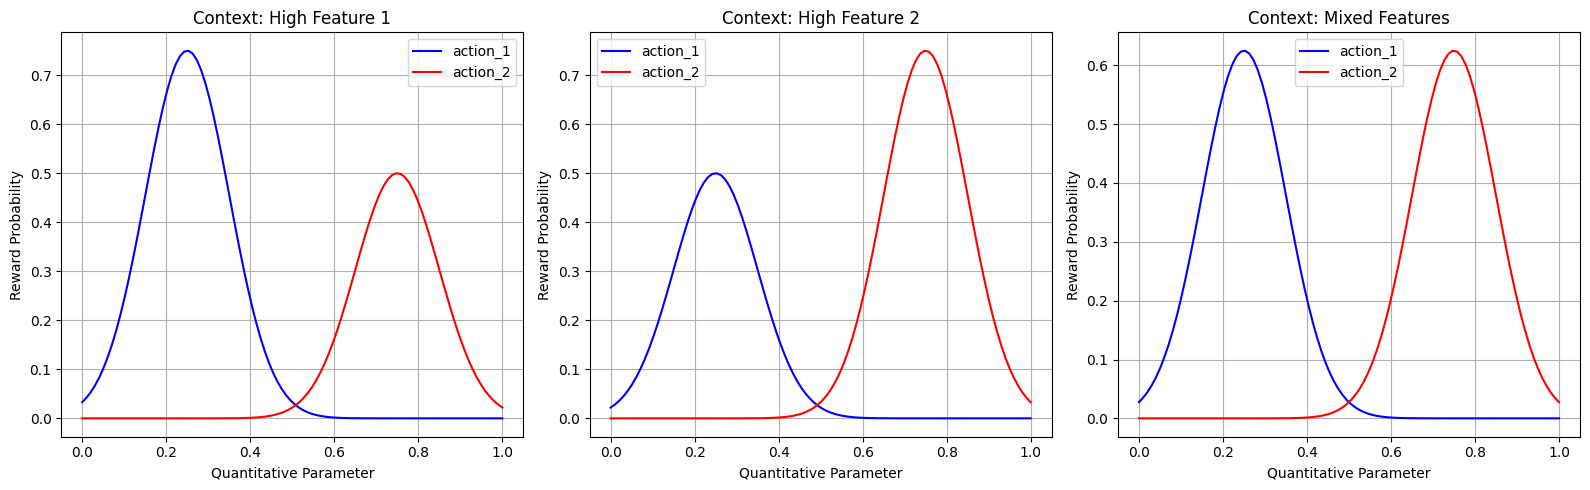

In [7]:
x = np.linspace(0, 1, 100)

# Plot for three different contexts
contexts = [
    np.array([1.0, 0.0, 0.0]),  # High first feature
    np.array([0.0, 1.0, 0.0]),  # High second feature
    np.array([0.5, 0.5, 0.0]),  # Mixed features
]

plt.figure(figsize=(16, 5))
for i, context in enumerate(contexts, 1):
    plt.subplot(1, 3, i)

    y1 = [np.exp(-((xi - 0.25) ** 2) / 0.02) * (0.5 + 0.5 * (context[0] / 2)) for xi in x]
    y2 = [np.exp(-((xi - 0.75) ** 2) / 0.02) * (0.5 + 0.5 * (context[1] / 2)) for xi in x]

    plt.plot(x, y1, "b-", label="action_1")
    plt.plot(x, y2, "r-", label="action_2")
    plt.xlabel("Quantitative Parameter")
    plt.ylabel("Reward Probability")

    if i == 1:
        title = "Context: High Feature 1"
    elif i == 2:
        title = "Context: High Feature 2"
    else:
        title = "Context: Mixed Features"

    plt.title(title)
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

## Generate Synthetic Context Data

Let's create synthetic context data for our experiment:

In [8]:
# Generate random context data
batch_sizes = [20000, 300, 300, 300, 300, 300]
context_data_sample = np.random.uniform(0, 1, (5, n_features))

# Preview the context data
pd.DataFrame(context_data_sample[:5], columns=[f"Feature {i + 1}" for i in range(n_features)])

,Feature 1,Feature 2,Feature 3
0,0.285021,0.607513,0.024831
1,0.032749,0.135545,0.860995
2,0.442315,0.812308,0.970485
3,0.527797,0.008870,0.876337
4,0.388934,0.955912,0.262616


## Bandit Training Loop

Now, let's train our bandit by simulating interactions for several rounds:

In [9]:
for iter, batch_size in enumerate(batch_sizes):
    if iter > 0:
        cmab = CmabBernoulli(actions=actions, epsilon=0)  # no exploration

    # Get context for this round
    current_context = np.random.uniform(0, 1, (batch_size, n_features))

    # Predict best action
    pred_actions, model_probs, weighted_sums = cmab.predict(context=current_context)
    chosen_actions = [a[0] for a in pred_actions]
    chosen_quantities = [a[1][0] for a in pred_actions]

    # Observe reward
    rewards_and_probs = [
        reward_function(chosen_action, chosen_quantity, _current_context)
        for chosen_action, chosen_quantity, _current_context in zip(chosen_actions, chosen_quantities, current_context)
    ]
    rewards = [reward_and_prob[0] for reward_and_prob in rewards_and_probs]
    probs = [reward_and_prob[1] for reward_and_prob in rewards_and_probs]

    optimal_probs = [get_optimal_reward(context) for context in current_context]

    regret = np.mean(np.array(optimal_probs) - np.array(probs))

    # Update bandit
    cmab.update(actions=chosen_actions, rewards=rewards, context=current_context, quantities=chosen_quantities)

    # Print progress
    print(f"Completed {iter} batches. Avg regret: {regret}")

SVI:   0%|          | 0/50 [00:00<?, ?it/s]

SVI:   2%|▏         | 1/50 [00:01<01:03,  1.30s/it]

SVI:   2%|▏         | 1/50 [00:01<01:03,  1.30s/it, loss=77478.6328]

SVI:   4%|▍         | 2/50 [00:01<01:02,  1.30s/it, loss=304541.3125]

SVI:   6%|▌         | 3/50 [00:01<01:01,  1.30s/it, loss=210038.8125]

...

SVI:  94%|█████████▍| 47/50 [00:01<00:03,  1.17s/it, loss=428.6164]

SVI:  96%|█████████▌| 48/50 [00:01<00:02,  1.17s/it, loss=1020.9066]

SVI:  98%|█████████▊| 49/50 [00:01<00:01,  1.17s/it, loss=333.9090] 

SVI: 100%|██████████| 50/50 [00:01<00:00,  1.17s/it, loss=484.0203]

Completed 5 batches. Avg regret: 0.5836880209741591


In [10]:
### Plot Reward surface - actual vs. predicted

[Text(0.5, 1.0, 'action_2'),
 Text(0, 0.5, 'Second feature'),
 Text(0.5, 0, 'Quantitative Parameter')]

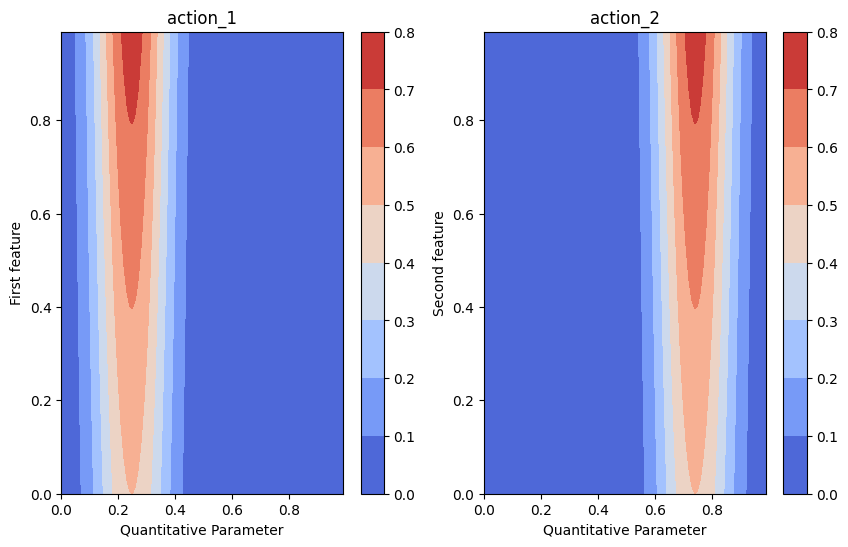

In [11]:
grid = np.mgrid[0:1:0.01, 0:1:0.01].astype(float)
grid_2d = grid.reshape(2, -1).T
plt.figure(figsize=(10, 6))
ax = plt.subplot(1, 2, 1)
y_true = np.zeros((100, 100))
reward_prob = np.zeros((100, 100))
for i, quantity in enumerate(np.linspace(0, 1, 100)):
    for j, first_feature in enumerate(np.linspace(0, 1, 100)):
        y_true[i, j], reward_prob[i, j] = reward_function(
            action="action_1", quantity=quantity, context=[first_feature, 0, 0]
        )

cmap = plt.get_cmap("coolwarm")
# Create the contour plot
contour = ax.contourf(*grid, reward_prob.reshape(100, 100), cmap=cmap)
cbar = plt.colorbar(contour, ax=ax)
ax.set(title="action_1", ylabel="First feature", xlabel="Quantitative Parameter")

ax = plt.subplot(1, 2, 2)
y_true = np.zeros((100, 100))
reward_prob = np.zeros((100, 100))
for i, quantity in enumerate(np.linspace(0, 1, 100)):
    for j, second_feature in enumerate(np.linspace(0, 1, 100)):
        y_true[i, j], reward_prob[i, j] = reward_function(
            action="action_2", quantity=quantity, context=[0, second_feature, 0]
        )

cmap = plt.get_cmap("coolwarm")
# Create the contour plot
contour = ax.contourf(*grid, reward_prob.reshape(100, 100), cmap=cmap)
cbar = plt.colorbar(contour, ax=ax)
ax.set(title="action_2", ylabel="Second feature", xlabel="Quantitative Parameter")

In [12]:
grid_2d_action_1 = np.append(grid_2d, np.zeros((grid_2d.shape[0], 2)), axis=1)

batch_predictions_action_1 = [
    cmab.actions["action_1"].bnn.sample_proba(grid_2d_action_1, rng=rng) for _ in range(500)
]  # predictions are list of tuples of probabilities and corresponding weighted sums
batch_proba_action_1 = np.array(
    [
        [proba_and_weighted_sum[0] for proba_and_weighted_sum in predictions]
        for predictions in batch_predictions_action_1
    ]
)

grid_2d_action_2 = np.concatenate(
    [grid_2d[:, 0:1], np.zeros((grid_2d.shape[0], 1)), grid_2d[:, 1:2], np.zeros((grid_2d.shape[0], 1))], axis=1
)

batch_predictions_action_2 = [
    cmab.actions["action_2"].bnn.sample_proba(grid_2d_action_2, rng=rng) for _ in range(500)
]  # predictions are list of tuples of probabilities and corresponding weighted sums
batch_proba_action_2 = np.array(
    [
        [proba_and_weighted_sum[0] for proba_and_weighted_sum in predictions]
        for predictions in batch_predictions_action_2
    ]
)

[Text(0, 0.5, 'Second feature'), Text(0.5, 0, 'Quantitative Parameter')]

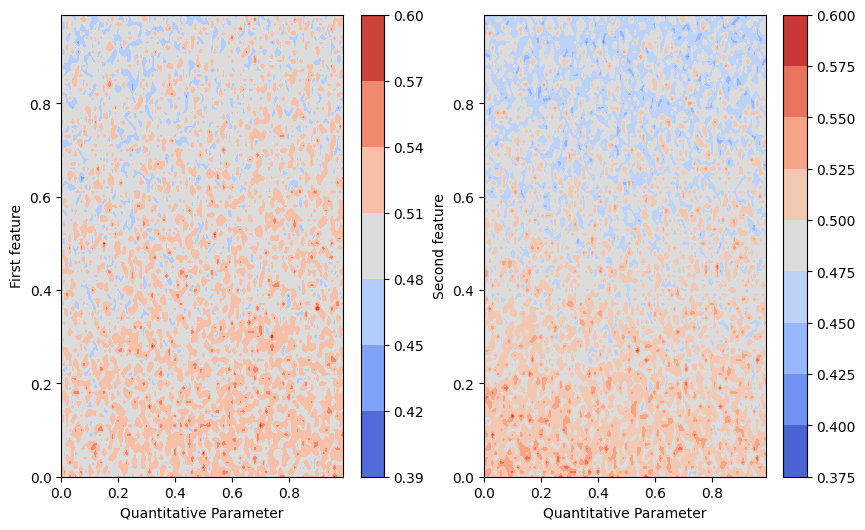

In [13]:
plt.figure(figsize=(10, 6))
ax = plt.subplot(1, 2, 1)
cmap = plt.get_cmap("coolwarm")

# Create the contour plot
pred_proba_mean = batch_proba_action_1.mean(axis=0)
contour = ax.contourf(*grid, pred_proba_mean.reshape(100, 100), cmap=cmap)
cbar = plt.colorbar(contour, ax=ax)
ax.set(ylabel="First feature", xlabel="Quantitative Parameter")

ax = plt.subplot(1, 2, 2)
pred_proba_mean = batch_proba_action_2.mean(axis=0)
contour = ax.contourf(*grid, pred_proba_mean.reshape(100, 100), cmap=cmap)
cbar = plt.colorbar(contour, ax=ax)
ax.set(ylabel="Second feature", xlabel="Quantitative Parameter")

## Testing with Specific Contexts

Finally, let's test our trained bandit with specific contexts to see if it has learned the optimal policy:

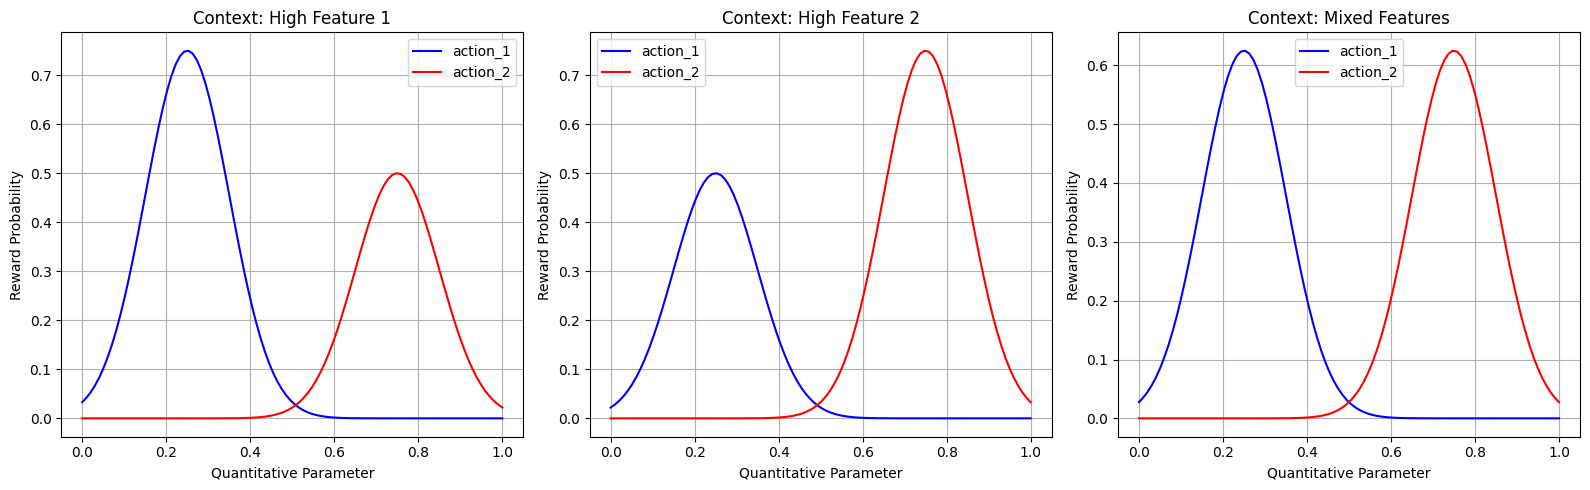

In [14]:
x = np.linspace(0, 1, 100)
n_samples = 100

# Plot for three different contexts
context = (np.array([1.0, 0.0, 0.0] * n_samples),)  # High first feature # Mixed features

plt.figure(figsize=(16, 5))
for i, context in enumerate(contexts, 1):
    plt.subplot(1, 3, i)

    y1 = [np.exp(-((xi - 0.25) ** 2) / 0.02) * (0.5 + 0.5 * (context[0] / 2)) for xi in x]
    y2 = [np.exp(-((xi - 0.75) ** 2) / 0.02) * (0.5 + 0.5 * (context[1] / 2)) for xi in x]

    plt.plot(x, y1, "b-", label="action_1")
    plt.plot(x, y2, "r-", label="action_2")
    plt.xlabel("Quantitative Parameter")
    plt.ylabel("Reward Probability")

    if i == 1:
        title = "Context: High Feature 1"
    elif i == 2:
        title = "Context: High Feature 2"
    else:
        title = "Context: Mixed Features"

    plt.title(title)
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

In [15]:
# Define test contexts
test_contexts = np.array(
    [
        [1.0, 0.0, 0.0],  # High feature 1, low feature 2
        [0.0, 1.0, 0.0],  # Low feature 1, high feature 2
        [1.0, 1.0, 0.0],  # High feature 1 and 2
        [0.0, 0.0, 0.0],  # Low feature 1 and 2
    ]
)

# Test predictions
results = []
for i, context in enumerate(test_contexts):
    context_reshaped = context.reshape(1, -1)
    pred_actions, probs, weighted_sums = cmab.predict(context=context_reshaped)
    chosen_action_quantity = pred_actions[0]
    chosen_action = chosen_action_quantity[0]
    chosen_quantities = chosen_action_quantity[1][0]
    chosen_action_probs = probs[0][chosen_action](chosen_quantities)

    # Sample optimal quantity for the chosen action
    # In a real application, you would have a method to test different quantities
    # Here we'll use our knowledge of the true optimal values
    if chosen_action == "action_1":
        optimal_quantity = 0.25
    else:
        optimal_quantity = 0.75

    # Expected reward probability
    expected_reward = reward_function(chosen_action, optimal_quantity, context)

    results.append(
        {
            "Context": context,
            "Chosen Action": chosen_action,
            "Chosen Quantity": chosen_quantities,
            "Action Probabilities": chosen_action_probs,
            "Optimal Quantity": optimal_quantity,
            "Expected Reward": expected_reward,
        }
    )

# Display results
for i, result in enumerate(results):
    context_type = ""
    if i == 0:
        context_type = "High feature 1, low feature 2"
    elif i == 1:
        context_type = "Low feature 1, high feature 2"
    elif i == 2:
        context_type = "High feature 1 and 2"
    elif i == 3:
        context_type = "Low feature 1 and 2"

    print(f"\nTest {i + 1}: {context_type}")
    print(f"Context: {result['Context']}")
    print(f"Chosen Action: {result['Chosen Action']}")
    print(f"Chosen Quantity: {result['Chosen Quantity']}")
    print(f"Action Probabilities: {result['Action Probabilities']}")
    print(f"Optimal Quantity: {result['Optimal Quantity']:.2f}")
    print(f"Expected Reward: {result['Expected Reward']}")


Test 1: High feature 1, low feature 2
Context: [1. 0. 0.]
Chosen Action: action_2
Chosen Quantity: 0.34797440524727696
Action Probabilities: 0.999999694097773
Optimal Quantity: 0.75
Expected Reward: (0, np.float64(0.5))

Test 2: Low feature 1, high feature 2
Context: [0. 1. 0.]
Chosen Action: action_1
Chosen Quantity: 0.9999999829685418
Action Probabilities: 0.999999694097773
Optimal Quantity: 0.25
Expected Reward: (0, np.float64(0.5))

Test 3: High feature 1 and 2
Context: [1. 1. 0.]
Chosen Action: action_1
Chosen Quantity: 0.7833402094885187
Action Probabilities: 0.999999694097773
Optimal Quantity: 0.25
Expected Reward: (1, np.float64(0.75))

Test 4: Low feature 1 and 2
Context: [0. 0. 0.]
Chosen Action: action_1
Chosen Quantity: 0.1751396374384713
Action Probabilities: 0.999999694097773
Optimal Quantity: 0.25
Expected Reward: (0, np.float64(0.5))


In [16]:
result

{'Context': array([0., 0., 0.]),
 'Chosen Action': 'action_1',
 'Chosen Quantity': np.float64(0.1751396374384713),
 'Action Probabilities': np.float64(0.999999694097773),
 'Optimal Quantity': 0.25,
 'Expected Reward': (0, np.float64(0.5))}

## Conclusion

The CMAB BNN-based quantitative model uses a Bayesian Neural Network to map context and continuous action parameters to reward distributions. This approach enables efficient exploration and exploitation of continuous or fine-grained action parameters while conditioning on context. The BNN provides uncertainty estimates (e.g., via variational inference) that the bandit uses for Thompson sampling or similar strategies, balancing exploration of uncertain regions with exploitation of high predicted rewards.

This approach is particularly useful when:
1. Actions have continuous parameters (e.g., price, dosage, bid) that affect rewards
2. The reward function depends on both context and action parameters
3. The optimal parameter values may vary across different contexts
4. You want a single differentiable model (BNN) over the full parameter space rather than adaptive discretization

Real-world applications include:
- **Personalized pricing**: Find optimal prices (continuous parameter) based on customer features (context)
- **Content recommendation**: Optimize content parameters (e.g., length, complexity) based on user demographics
- **Medical dosing**: Determine optimal medication dosages based on patient characteristics
- **Ad campaign optimization**: Find best bid values based on ad placement and target audience